### Campos del Recurso y Clasificación Estadística

Esta tabla resume la descripción de cada variable y su clasificación estadística para el análisis.

| Variable | Descripción | Tipo Estadístico | Nivel |
| :--- | :--- | :--- | :--- |
| **long** | Longitud geográfica (X coordinate). | Cuantitativa | Continua |
| **lat** | Latitud geográfica (Y coordinate). | Cuantitativa | Continua |
| **nro_registro** | Número de registro único del árbol. | Cualitativo | Nominal |
| **tipo_activ** | Tipo de actividad o clasificación del árbol. | Cualitativo | Nominal |
| **comuna** | Número de la comuna. | Cualitativo | Nominal |
| **manzana** | Identificador de la manzana. | Cualitativo | Nominal |
| **calle_nombre** | Nombre de la calle. | Cualitativo | Nominal |
| **calle_altura** | Altura de la calle (numérico). | Cuantitativo | Discreto |
| **calle_chapa** | Número de chapa de la calle más cercano. | Cuantitativo | Discreto |
| **direccion_normalizada** | Dirección normalizada. | Cualitativo | Nominal |
| **ubicacion** | Información adicional sobre la ubicación. | Cualitativo | Nominal |
| **nombre_cientifico** | Nombre científico de la especie. | Cualitativo | Nominal |
| **ancho_acera** | Ancho de la acera, en metros. | Cuantitativo | Continuo |
| **estado_plantera** | Estado de la plantación. | Cualitativo | Nominal |
| **ubicacion_plantera** | Condición de la ubicación de la plantación. | Cualitativo | Nominal |
| **nivel_plantera** | Nivel de la plantación respecto al suelo. | Cualitativo | Nominal |
| **diametro_altura_pecho** | Diámetro del árbol a la altura del pecho, en centímetros. | Cuantitativo | Continuo |
| **altura_arbol** | Altura del árbol en metros. | Cuantitativo | Continuo |


In [1]:

from wget import download
from os import path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from scipy import stats
from scipy.stats import chi2, chi2_contingency,levene, shapiro,probplot
import geopandas as gpd
from shapely.geometry import Point

#abrimos el archivo de base de datos
if not path.exists("arbolado-publico-lineal-2017-2018.csv"):
  download("https://cdn.buenosaires.gob.ar/datosabiertos/datasets/atencion-ciudadana/arbolado-publico-lineal/arbolado-publico-lineal-2017-2018.csv")
else:
  print("El archivo ya existe")

dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")

dataset.info()
#dataset.describe()
dataset["nro_registro"].value_counts()



El archivo ya existe


C:\Users\Eliana\AppData\Local\Temp\ipykernel_11084\971632128.py:21: DtypeWarning: Columns (2,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  dataset = pd.read_csv("arbolado-publico-lineal-2017-2018.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370180 entries, 0 to 370179
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   354838 non-null  float64
 1   lat                    354838 non-null  float64
 2   nro_registro           370180 non-null  object 
 3   tipo_activ             370180 non-null  object 
 4   comuna                 370180 non-null  int64  
 5   manzana                224140 non-null  object 
 6   calle_nombre           370087 non-null  object 
 7   calle_altura           364677 non-null  object 
 8   calle_chapa            363721 non-null  object 
 9   direccion_normalizada  355941 non-null  object 
 10  ubicacion              361884 non-null  object 
 11  nombre_cientifico      370180 non-null  object 
 12  ancho_acera            367083 non-null  object 
 13  estado_plantera        370180 non-null  object 
 14  ubicacion_plantera     368776 non-nu

nro_registro
26779     1
141227    1
141225    1
141224    1
141222    1
         ..
407934    1
407933    1
407932    1
407931    1
546144    1
Name: count, Length: 370180, dtype: int64

### LIMPIEZA 
**lat y long:** Valores correctos. Nada para limpiar.

**nro_registro:** Vemos que es de tipo object en lugar de entero. Revisamos cuales son los valores no numericos que tiene la columna. Solo hay un tipo de valor no numérico en toda la columna(}). Reemplazamos ese carácter por NaN y luego convertimos toda la columna a un tipo numérico

**tipo_activ:** Decidimos eliminar esta columna. Tenemos la mayoria de las muestras con valores LINEAL y la otra opcion (CALLE) no logramos deducir que significa. No nos aporta nada relevante para las hipotesis que planteamos. 

**manzana:** Segun nuestra busqueda en internet, las letras presentes en los valores de manzana representan la parcela donde se encuentra el arbol. Es por esto que decidimos removerlo, no forma parte de la variable manzana y tampoco es relevante para nuestras hipotesis ponerlo en una columna "parcela". Ademas, habia muchos valores con espacion vacios por lo que los pasamos a NaN.

**calle_nombre:** Eliminamos espacios, puntos, comas y pasamos todo a minusculas para evitar errores.

**calle_altura:** Buscamos si no hay valores decimales, al no encontrar pasamos los datos a Int64.

**calle_chapa:** Buscamos si no hay valores decimales, como hay los dejamos como float.

**direccion_normalizada:** pasamos todo a minuscula y sacamos los espacios en blanco, comas y simbolos. Vemos que los nulos estan cargados como el string "nan" asi que los pasamos a NaN.

**ubicacion:** La variable tiene valores como "exacta" y despues cosas como "la", "ld" "l1". Al no tener mas informacion al respecto decidimos cambiar a una variable dicotomica "ubicacion_exacta" donde sea 1 para todas las muestras que tenian "exacta" y 0 para todo el resto.

**nombre_cientifico:** pasamos todo a minuscula, nada mas para limpiar.

**ancho_acera:** Eliminamos espacios, simbolos o letras, cambiamos "," por "." y pasamos a float

**estado_plantera:** paso a minusculas y borro las palabras que estan de mas.

**ubicacion_plantera:** paso a minusculas, agrego las letras que faltan y paso "nan" a nulos. Hay valores que pertenecen a las variables "estado_plantera" y "nivel_plantera", entonces en caso que tengan nulo en estas variables pasamos el valor y en "ubicacion_plantera" ponemos nulos."Cantero grande" no es un valor valido para la ubicacion y tampoco tiene relacion con otras variables, por lo tanto lo eliminamos. 
Por ultimo, vemos que se estan guardando dos variables binarias a la vez: la ubicacion de la plantera [ochava o regular(consideramos regular como un arbol en una vereda paralela a la calle)] y si esta o no fuera de linea. Para aquellas muestras que solo dicen "fuera de linea" pero no sabemos si es ochava o regular, miramos la lat y long y las buscamos en Google Maps; logramos ver que eran ubicaciones regulares asi que las cargamos como tal.
que hacemos con los nulos????

**nivel_plantera:** paso a minusculas, elimino espacios y agrupo valores como EL,elevadas,elevado,... por elevada. cambio los strings "nan" y "obs" por NaN de pandas. Hay valores que pertenecen a la variable "ubicacion_plantera", entonces en caso que tengan nulo en esta variable pasamos el valor y en "nivel_plantera" ponemos nulos.

**diametro_altura_pecho:** Variable limpia. No modificamos nada.

**altura_arbol:** Variable limpia. No modificamos nada.

In [2]:
copiaDataset= dataset

#-----COLUMNA "NRO_REGISTRO"-----
# Filtrar valores que realmente sean strings
solo_strings = copiaDataset["nro_registro"].apply(lambda x: isinstance(x, str))
# Aplicar .str solo sobre esos valores convertidos explícitamente a string
no_numericos = (
    copiaDataset.loc[solo_strings, "nro_registro"]
    .astype(str)
    .loc[lambda s: ~s.str.isnumeric()]
)
no_numericos.unique()
# Reemplazar los '}' por NaN
copiaDataset["nro_registro"] = copiaDataset["nro_registro"].replace("}", np.nan)
# Convertir todo a numérico (float o int). 
# "errors='coerce'" convierte a NaN cualquier cosa que no sea número.
copiaDataset["nro_registro"] = pd.to_numeric(copiaDataset["nro_registro"], errors='coerce')
# Convertir a entero con soporte para NaN (para evitar el .0)
copiaDataset["nro_registro"] = copiaDataset["nro_registro"].astype("Int64")

#-----COLUMNA "TIPO_ACTIV"
copiaDataset=copiaDataset.drop(columns=["tipo_activ"])

#-----COLUMNA "MANZANA"
copiaDataset["manzana"] = copiaDataset["manzana"].astype(str)
copiaDataset["manzana"] = copiaDataset["manzana"].str.replace(r'[^0-9]', '',  regex=True)
# Cuántos son realmente NaN
print("NaN reales:", copiaDataset["manzana"].isna().sum())
# Cuántos son cadenas vacías o solo espacios
print("Cadenas vacías o espacios:", (copiaDataset["manzana"].str.strip() == "").sum())
# Reemplazar espacios vacíos por NaN
copiaDataset["manzana"] = copiaDataset["manzana"].replace(r"^\s*$", pd.NA, regex=True)
#los pasamos a valores numericos en lugar de tipo object
copiaDataset["manzana"] = pd.to_numeric(copiaDataset["manzana"], errors="coerce").astype("Int64")

#-----COLUMNA "CALLE_NOMBRE"
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].astype(str).str.strip().str.lower()
copiaDataset["calle_nombre"] = copiaDataset["calle_nombre"].str.replace(r'[^a-z ]', '',  regex=True)

#-----COLUMNA "CALLE_ALTURA"
copiaDataset["calle_altura"] = pd.to_numeric(copiaDataset["calle_altura"], errors='coerce')#convierto la col en numerica, todo en float y si no NaN
(copiaDataset["calle_altura"] % 1 != 0).any()#veo si hay valores decimales
copiaDataset["calle_altura"] = copiaDataset["calle_altura"].astype(float).astype("Int64") #como no hay pasamos a Int64

#-----COLUMNA "CALLE_CHAPA"
copiaDataset["calle_chapa"] = pd.to_numeric(copiaDataset["calle_chapa"], errors='coerce')#convierto la col en numerica, todo en float y si no NaN
(copiaDataset["calle_chapa"] % 1 != 0).any()#veo si hay valores decimales y si hay, lo dejo como float

#-----COLUMNA "DIRECCION_NORMALIZADA"
copiaDataset["direccion_normalizada"] = (copiaDataset["direccion_normalizada"].astype(str).str.strip().str.lower())
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r',', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].str.replace(r'[^a-z0-9áéíóúñ ]', '', regex=True)
copiaDataset["direccion_normalizada"].value_counts() #aca vemos que hay un monton de nulos cargados con el string "nan"
copiaDataset["direccion_normalizada"].isna().sum() #y que no hay nulos verdaderos
copiaDataset["direccion_normalizada"] = copiaDataset["direccion_normalizada"].replace("nan", np.nan) #los pasamos a NaN

#-----COLUMNA "UBICACION"
copiaDataset["ubicacion"] = copiaDataset["ubicacion"].astype(str).str.strip().str.lower()
# Crear variable dicotómica
copiaDataset["ubicacion_exacta"] = (copiaDataset["ubicacion"] == "exacta").astype(int)
copiaDataset.drop(columns=["ubicacion"], inplace=True)

#-----COLUMNA "NOMBRE_CIENTIFICO"
copiaDataset["nombre_cientifico"] = copiaDataset["nombre_cientifico"].astype(str).str.strip().str.lower()

#-----COLUMNA "ANCHO_ACERA"
copiaDataset["ancho_acera"] = (
    copiaDataset["ancho_acera"]
    .str.replace(r"[^0-9,.\-]", "", regex=True)   # quita $, m, espacios, letras, etc.
    .str.replace(",", ".", regex=False)           # reemplaza coma por punto decimal
    .str.strip()                                  # quita espacios
)
copiaDataset["ancho_acera"] = pd.to_numeric(copiaDataset["ancho_acera"], errors="coerce")

#-----COLUMNA "ESTADO_PLANTERA"
copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].astype(str).str.strip().str.lower()
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('cantero ', '', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace('ocupado', 'ocupada', regex=False)
copiaDataset["estado_plantera"] = copiaDataset ["estado_plantera"].str.replace("parc.","parcialmente", regex=False)
copiaDataset["estado_plantera"] = copiaDataset["estado_plantera"].str.replace(r'\s+', ' ', regex=True)

#-----COLUMNA "UBICACION_PLANTERA"
copiaDataset["ubicacion_plantera"] = copiaDataset["ubicacion_plantera"].astype(str).str.strip().str.lower()
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^ochva$", 'ochava', regex=True) #indica inicio y fin de cadena, para que no modifique cuando contiene la palabra
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^o$", 'ochava', regex=True)
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"^och$", 'ochava', regex=True)
copiaDataset["ubicacion_plantera"] = copiaDataset ["ubicacion_plantera"].str.replace(r"fuera línea", "fuera de línea", regex=True)
copiaDataset = copiaDataset[copiaDataset["ubicacion_plantera"] != "cantero grande"]
copiaDataset["ubicacion_plantera"]=copiaDataset["ubicacion_plantera"].replace("nan", np.nan)
#Máscaras según las categorías que corresponden a otras variables
mask_estado = copiaDataset["ubicacion_plantera"].isin(["ocupada", "subocupada", "sobreocupada"])
mask_nivel = copiaDataset["ubicacion_plantera"].isin(["elevada","fuera nivel"])
#Si el estado está nulo y ubicacion_plantera tiene esos valores, los pasamos
copiaDataset.loc[mask_estado & copiaDataset["estado_plantera"].isna(), "estado_plantera"] = \
    copiaDataset.loc[mask_estado & copiaDataset["estado_plantera"].isna(), "ubicacion_plantera"]
copiaDataset.loc[mask_nivel & copiaDataset["nivel_plantera"].isna(), "nivel_plantera"] = \
    copiaDataset.loc[mask_nivel & copiaDataset["nivel_plantera"].isna(), "ubicacion_plantera"]
#Ponemos NaN en ubicacion_plantera
copiaDataset.loc[mask_estado | mask_nivel, "ubicacion_plantera"] = np.nan
#manejo de "fuera de linea"
# Crear columnas con 0
copiaDataset["es_regular"] = 0
copiaDataset["fuera_de_linea"] = 0
# 1️⃣ Caso más específico: "ochava" y "fuera de línea" → 0 y 1
mask_ambos = (
    copiaDataset["ubicacion_plantera"].str.contains("ochava", na=False)
    & copiaDataset["ubicacion_plantera"].str.contains("fuera de línea", na=False)
)
copiaDataset.loc[mask_ambos, ["es_regular", "fuera_de_linea"]] = [0, 1]
# 2️⃣ "fuera de línea" solo → 1 y 1
mask_fuera = (
    copiaDataset["ubicacion_plantera"].str.contains("fuera de línea", na=False)
    & ~mask_ambos
)
copiaDataset.loc[mask_fuera, ["es_regular", "fuera_de_linea"]] = [1, 1]
# 3️⃣ "regular" → 1 y 0
mask_regular = copiaDataset["ubicacion_plantera"] == "regular"
copiaDataset.loc[mask_regular, ["es_regular", "fuera_de_linea"]] = [1, 0]
# 4️⃣ "ochava" solo → 0 y 0
mask_ochava = (
    copiaDataset["ubicacion_plantera"].str.contains("ochava", na=False)
    & ~mask_ambos
)
copiaDataset.loc[mask_ochava, ["es_regular", "fuera_de_linea"]] = [0, 0]

#-----COLUMNA "NIVEL_PLANTERA"
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].astype(str).str.strip().str.lower()
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].str.replace(r'\s+', ' ', regex=True)
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["elevadas","eleveda","el","elevado"],"elevada")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["bn","bajo bivel","baja nivel","reducida"],"bajo nivel")
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["an"],"a nivel")
mask_ubicacion = copiaDataset["nivel_plantera"].isin(["ochava", "regular"])
#Si la ubicacion es nulo y nivel_plantera tiene esos valores, los pasamos
copiaDataset.loc[mask_ubicacion & copiaDataset["ubicacion_plantera"].isna(), "ubicacion_plantera"] = \
    copiaDataset.loc[mask_ubicacion & copiaDataset["ubicacion_plantera"].isna(), "nivel_plantera"]
#Ponemos NaN en nivel_plantera
copiaDataset.loc[mask_ubicacion, "nivel_plantera"] = np.nan
copiaDataset["nivel_plantera"] = copiaDataset["nivel_plantera"].replace(["nan","obs: no tiene plantera definida"],np.nan)

copiaDataset["nro_registro"].value_counts()

NaN reales: 0
Cadenas vacías o espacios: 146623


nro_registro
26779     1
141232    1
141230    1
141229    1
141228    1
         ..
407932    1
407931    1
407930    1
407929    1
546144    1
Name: count, Length: 370166, dtype: Int64

### Análisis Univariado

#### Hipotesis 1
- Las comunas del norte de la Ciudad de Buenos Aires (12, 13 y 14) 
presentan mayor densidad de árboles por superficie urbana que las comunas del sur (4, 8 y 9).

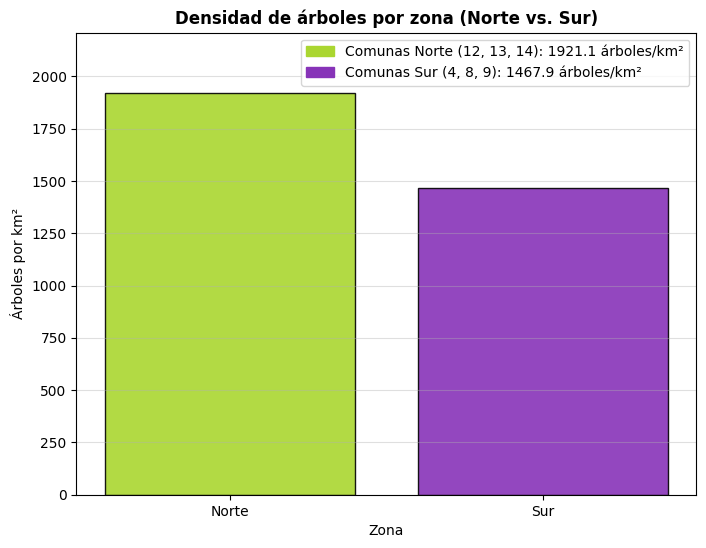

In [3]:
superficies = {     #en km²
    1: 17.9,  2: 6.3,  3: 6.4,  4: 22.7,  5: 6.7,
    6: 6.9,  7: 12.4, 8: 22.5, 9: 16.6, 10: 12.6,
    11: 14.1, 12: 15.7, 13: 15.0, 14: 15.9, 15: 14.3
}

# Asumo que 'copiaDataset' está disponible.
datasetH1 = copiaDataset[["comuna"]].copy()

# Contar cantidad de árboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")
# Agregar la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)
# Calcular densidad de árboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# Definir grupos
grupo_norte = [12, 13, 14]
grupo_sur = [4, 8, 9]

# Clasificar cada comuna en una zona
def asignar_zona(comuna):
    if comuna in grupo_norte:
        return "Norte"
    elif comuna in grupo_sur:
        return "Sur"
    return None  # evita NaNs en comunas que no pertenecen a la hipótesis

arboles_por_comuna["zona"] = arboles_por_comuna["comuna"].apply(asignar_zona)

# Agrupar por zona sumando árboles y superficie
zona_resumen = arboles_por_comuna.groupby("zona").agg(
    arboles_totales=("cantidad_arboles", "sum"),
    superficie_total=("superficie", "sum")
).reset_index()

# Calcular densidad por zona
zona_resumen["densidad"] = zona_resumen["arboles_totales"] / zona_resumen["superficie_total"]

# Extracción de la densidad para el Norte
densidad_norte = zona_resumen[zona_resumen["zona"] == "Norte"]["densidad"].iloc[0]
# Extracción de la densidad para el Sur
densidad_sur = zona_resumen[zona_resumen["zona"] == "Sur"]["densidad"].iloc[0]

# Colores
color_norte = "#AAD630"
color_sur = "#8733B8"
colores = [color_norte, color_sur]

# Gráfico
plt.figure(figsize=(8,6))
plt.bar(
    zona_resumen["zona"],
    zona_resumen["densidad"],
    color=colores,
    edgecolor="black",
    alpha=0.9
)

# Leyenda
norte_patch = mpatches.Patch(
    color=color_norte, 
    label=f'Comunas Norte (12, 13, 14): {densidad_norte:.1f} árboles/km²'
)
sur_patch = mpatches.Patch(
    color=color_sur, 
    label=f'Comunas Sur (4, 8, 9): {densidad_sur:.1f} árboles/km²'
)

# Añade la leyenda al gráfico
plt.legend(handles=[norte_patch, sur_patch], loc='upper right')

# Títulos y Ejes
plt.title("Densidad de árboles por zona (Norte vs. Sur)", fontweight="bold")
plt.xlabel("Zona")
plt.ylabel("Árboles por km²")
plt.grid(axis='y', linestyle='-', alpha=0.4)
plt.ylim(0, zona_resumen["densidad"].max() * 1.15)
plt.show()


### Análisis Univariado

#### Hipotesis 1
- "La distribución de la cantidad total de árboles por comuna es uniforme"

C:\Users\Eliana\AppData\Local\Temp\ipykernel_11084\2392683635.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


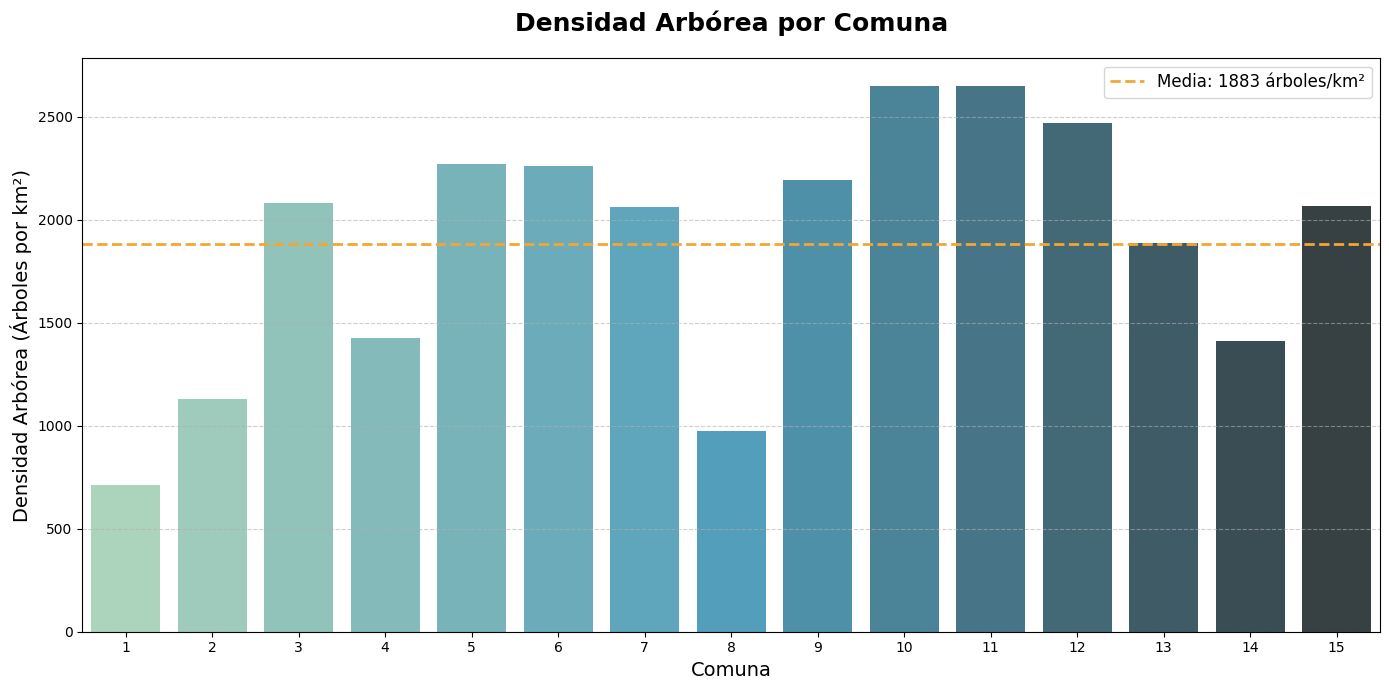

In [4]:
# Asumo que 'copiaDataset' está disponible.
datasetH1 = copiaDataset[["comuna"]].copy()

# Cuento cantidad de árboles por comuna
arboles_por_comuna = datasetH1.groupby("comuna").size().reset_index(name="cantidad_arboles")
# Agregar la superficie de cada comuna
arboles_por_comuna["superficie"] = arboles_por_comuna["comuna"].map(superficies)
# Calcular densidad de árboles por km²
arboles_por_comuna["densidad_arboles"] = arboles_por_comuna["cantidad_arboles"] / arboles_por_comuna["superficie"]

# Calculo de la media
densidad_media = arboles_por_comuna['densidad_arboles'].mean()

plt.figure(figsize=(14, 7))
# Gráfico de Barras: Comuna (categórica) vs. Densidad (cuantitativa)
sns.barplot(
    x="comuna",
    y="densidad_arboles",
    data=arboles_por_comuna,
    palette="GnBu_d" # Paleta
)

# Agregar la media como línea de referencia para evaluar la uniformidad
plt.axhline(densidad_media, color="#F2A634", linestyle="--", linewidth=2, label=f"Media: {densidad_media:.0f} árboles/km²")

# Personalización del gráfico
plt.title("Densidad Arbórea por Comuna", fontsize=18, pad=20, fontweight="bold")
plt.xlabel("Comuna", fontsize=14)
plt.ylabel("Densidad Arbórea (Árboles por km²)", fontsize=14)
plt.xticks(rotation=0)
plt.legend(fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Como se puede observar, algunas comunas tienen una cantidad de árboles significativamente mayor respecto a otras.
Esto indica una distribución desigual del arbolado urbano.

**Se rechaza la hipotesis planteada.**

### Hipotesis 2
- “El 80% de los árboles tienen una altura menor a  12 metros.”


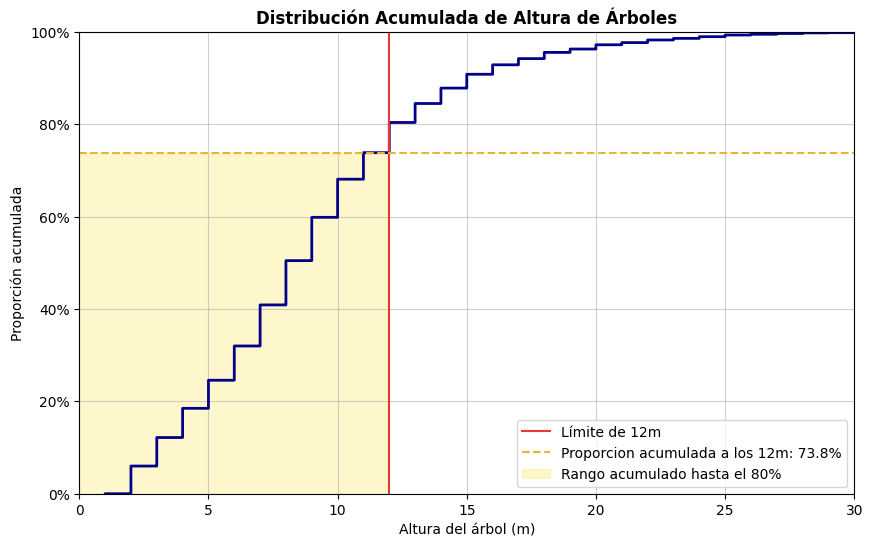

Número total de árboles (N): 365845
Árboles <= 12m (X): 270065
Proporción Real de la Muestra (p̂): 0.7382
Estadístico Z: -85.0348
Valor p (p-value): 0.0000

Resultado: Se rechaza la Hipótesis Nula (H0). La proporción es significativamente diferente de 80.0%.


In [12]:
limite = 12
proporcion_hipotesis = 0.80

datasetH2 = copiaDataset[["altura_arbol"]].copy()

# Cálculo del percentil 80
altura_p80 = np.percentile(copiaDataset["altura_arbol"].dropna(), 80)

# Cálculo de la proporción acumulada en el límite de 12 m
proporcion_12m_real = (copiaDataset["altura_arbol"].dropna() < limite).mean()  #DA 80.4%, NO ME DA COMO DIJO ROSANA (MENOS DEL 80%) -->ERA POR EL IGUAAAAAAL

plt.figure(figsize=(10, 6))

# crear el Gráfico de Distribución Acumulada (CDF)
sns.ecdfplot(data=copiaDataset, x='altura_arbol', color='darkblue', linewidth=2)

# Marcar los Límites de la Hipótesis (Eje X, 12 mt)
plt.axvline(x=limite, color="#EA3636", linestyle='-', linewidth=1.5, label=f"Límite de {limite}m")

# Línea Horizontal para el VALOR EN 12M 
plt.axhline(proporcion_12m_real, color="#EAB436", linestyle='--', linewidth=1.5, 
            label=f'Proporcion acumulada a los {limite}m: {proporcion_12m_real:.1%}')
#HACEMOS ESTA LINEA ?? O EN EL 80%??

# marca los porcentaje en eje Y
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))  # "1" indica que el máximo es 1.0 (100%)

# Sombrear SOLO hasta el percentil 80 
plt.axvspan(
    xmin=0,
    xmax=altura_p80,
    ymin=0,
    ymax=proporcion_12m_real,
    color='gold',
    alpha=0.20,
    label='Rango acumulado hasta el 80%'
)
#  Ajustar eje X para evitar demasiado espacio
plt.xlim(0, max(30, altura_p80 + 5))
# Etiquetas y título
plt.title("Distribución Acumulada de Altura de Árboles", fontsize=12, fontweight="bold")
plt.xlabel("Altura del árbol (m)")
plt.ylabel("Proporción acumulada")
plt.legend(loc='lower right')
plt.grid(True, linestyle='-', alpha=0.6)
plt.show()

"""inspeccion es el grafico
test proporcion , test t 
"""
from statsmodels.stats.proportion import proportions_ztest #ver si lo usamos, lo hice porq antes me daba 80,4% y queria ver la diferencia

# a) Calcular los valores requeridos (X y N)

arboles_sin_nan = copiaDataset["altura_arbol"].dropna()

# X = Número de "éxitos" (árboles < 12 metros)
exitos = (arboles_sin_nan < limite).sum()

# N = Número total de observaciones válidas
nobs = len(arboles_sin_nan)

# b) Realizar el Test de Proporción (Z-test)
z_stat, p_value = proportions_ztest(
    count=exitos, 
    nobs=nobs, 
    value=proporcion_hipotesis
)

# c) Imprimir resultados
print(f"Número total de árboles (N): {nobs}")
print(f"Árboles <= {limite}m (X): {exitos}")
print(f"Proporción Real de la Muestra (p̂): {exitos/nobs:.4f}")
print(f"Estadístico Z: {z_stat:.4f}")
print(f"Valor p (p-value): {p_value:.4f}")

# d) Conclusión (usando un nivel de significancia α=0.05)
alfa = 0.05
if p_value < alfa:
    print(f"\nResultado: Se rechaza la Hipótesis Nula (H0). La proporción es significativamente diferente de {proporcion_hipotesis*100}%.")
else:
    print(f"\nResultado: NO se rechaza la Hipótesis Nula (H0). La proporción no es significativamente diferente de {proporcion_hipotesis*100}%.")

 Se concluye que la proporción de árboles con altura menor a $12$ metros no es del $80\%$, sino que es significativamente menor, cercana al $73.8\%$
 
 El Test Z demuestra que la diferencia entre la proporción observada ($\mathbf{73.82}\%$) y la proporción postulada ($\mathbf{80.0}\%$) es estadísticamente significativa.
 
**Por lo tanto, se rechaza la hipótesis de que el 80% de los árboles tiene una altura menor a 12 metros.**

### Hipotesis 3
- La mediana del ancho de las aceras disponibles para el arbolado urbano en la Ciudad de Buenos Aires es superior a 2.5 metros.

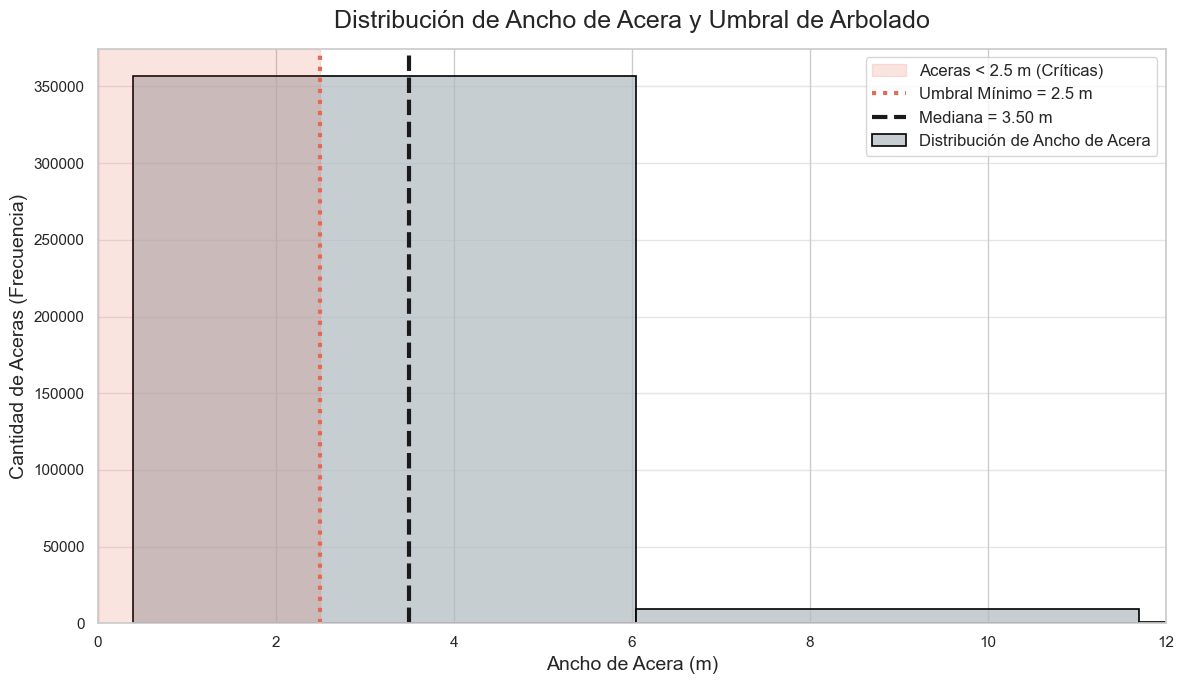

La mediana real de los datos es: 3.50 metros


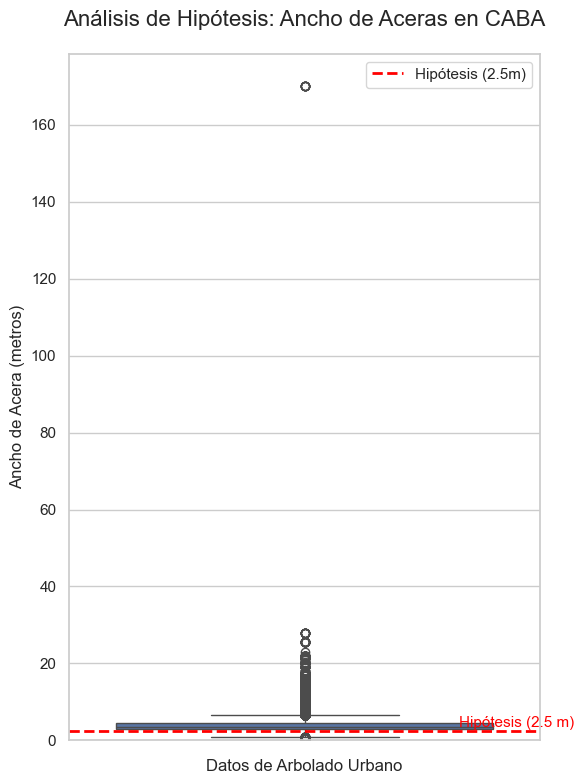

In [15]:
datasetH3 = copiaDataset[["ancho_acera"]].copy()

# Reemplaza la coma (,) por el punto (.)
#datasetH3['ancho_acera'] = datasetH3['ancho_acera'].str.replace(',', '.')

# Convierte a numérico
datasetH3['ancho_acera'] = pd.to_numeric(datasetH3['ancho_acera'], errors='coerce')


datasetH3["hipotesis_menor_2_5"] = datasetH3["ancho_acera"] < 2.5

# Cantidad de aceras que cumplen la hipótesis
cantidad = datasetH3["hipotesis_menor_2_5"].sum()

# Calcular la mediana
mediana = datasetH3["ancho_acera"].median()
#hola

"""
# Histograma
plt.figure(figsize=(10,6))
plt.hist(datasetH3["ancho_acera"], bins=20, color="skyblue", edgecolor="black")
plt.axvline(mediana, color="red", linestyle="dashed", linewidth=2, label=f"Mediana = {mediana:.2f} m")
plt.axvline(2.5, color="green", linestyle="dotted", linewidth=2, label="Umbral = 2.5 m")

plt.xlim(0, 12)
plt.xticks(np.arange(0, 12, 1))

plt.title("Distribución del ancho de acera")
plt.xlabel("Ancho de acera (m)")
plt.ylabel("Cantidad de arboles")
plt.legend()
plt.show() 
"""
#1. 📊 Histograma Mejorado (Distribución y Umbral Crítico)
# -----------------------------------------------------------------

plt.figure(figsize=(12, 7))

# Histograma de la distribución (Se quita el KDE para evitar la distorsión del eje Y)
sns.histplot(
    datasetH3['ancho_acera'].dropna(),
    bins=30,
    color="#AEBAC0",        # Azul claro
    edgecolor='black',      # Borde de la barra más oscuro
    linewidth=1.2,
    alpha=0.7,
    label='Distribución de Ancho de Acera'
)

# Sombreado para resaltar la zona problemática (< 2.5 m)
plt.axvspan(
    0, 2.5,
    color='#E34A33',        # Rojo/Naranja de advertencia
    alpha=0.15,             # Poca opacidad para ver las barras
    label='Aceras < 2.5 m (Críticas)'
)

# Línea del Umbral (2.5 m)
plt.axvline(
    2.5,
    color="#E26B58",        # Rojo/Naranja
    linestyle=':',
    linewidth=3,
    label=f'Umbral Mínimo = 2.5 m'
)

# Línea de la Mediana
plt.axvline(
    mediana,
    color='k',              # Negro
    linestyle='--',
    linewidth=3,
    label=f'Mediana = {mediana:.2f} m'
)

plt.title('Distribución de Ancho de Acera y Umbral de Arbolado', fontsize=18, pad=15)
plt.xlabel('Ancho de Acera (m)', fontsize=14)
plt.ylabel('Cantidad de Aceras (Frecuencia)', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.5)
plt.xlim(0, 12) # Limita el eje X hasta 12m para enfocar la distribución principal
plt.tight_layout()
plt.show()

#"La mediana del ancho de las aceras disponibles 
#para el arbolado urbano en la Ciudad de Buenos Aires es superior a 2.5 metros."

# 2. CALCULAR LA MEDIANA REAL (PARA VERIFICAR)
mediana_real = datasetH3['ancho_acera'].median()
print(f"La mediana real de los datos es: {mediana_real:.2f} metros")

# 3. CREAR EL GRÁFICO
valor_hipotesis = 2.5

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")

# Crear la figura
plt.figure(figsize=(6, 8)) # Altura (8) mayor que ancho (6) para un boxplot vertical

# Dibujar el Box Plot
ax = sns.boxplot(y=datasetH3['ancho_acera'])

# --- ESTA ES LA PARTE CLAVE ---
# Dibujar la línea horizontal roja que representa la hipótesis
plt.axhline(
    y=valor_hipotesis,          # Posición Y en 2.5 metros
    color='red',                # Color de la línea
    linestyle='--',             # Estilo de línea (punteada)
    linewidth=2,                # Grosor
    label=f'Hipótesis ({valor_hipotesis}m)' # Etiqueta
)

# Añadir un texto claro junto a la línea
plt.text(
    x=0.45,                     # Posición X (un poco a la derecha)
    y=valor_hipotesis + 0.05,   # Un poco arriba de la línea
    s=f'Hipótesis (2.5 m)',     # El texto a mostrar
    color='red',                
    va='bottom',                # Alineación vertical
    ha='center',                # Alineación horizontal
    fontsize=11
)
# --- FIN DE LA PARTE CLAVE ---


# 4. PERSONALIZAR TÍTULOS Y ETIQUETAS
plt.title('Análisis de Hipótesis: Ancho de Aceras en CABA', fontsize=16, pad=20)
plt.ylabel('Ancho de Acera (metros)', fontsize=12)
plt.xlabel('Datos de Arbolado Urbano', fontsize=12)

# Asegurarse de que el eje Y muestre bien nuestros valores
plt.ylim(bottom=0) # Que el eje Y empiece en 0

# Mostrar la leyenda (aunque el texto ya es claro)
plt.legend()

# Mostrar el gráfico
plt.tight_layout()
plt.show()
 


### ANALISIS BIVARIADO

### Hipotesis 4
- Existe una asociacion entre la comuna donde se encuentra el arbol y el estado de la plantera.


Conteo usando método .loc:
buen_estado
1    331001
0     39166
Name: count, dtype: int64
--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---
buen_estado  Mal Estado (%)  Buen Estado (%)  Total Planteras
comuna                                                       
1                      5.73            94.27            12723
2                      8.25            91.75             7115
3                      3.48            96.52            13320
4                      6.66            93.34            32343
5                      9.06            90.94            15224
6                      8.61            91.39            15591
7                      9.60            90.40            25608
8                      9.35            90.65            21968
9                     11.83            88.17            36405
10                    14.32            85.68            33421
11                    14.05            85.95            37340
12                    12.31            87

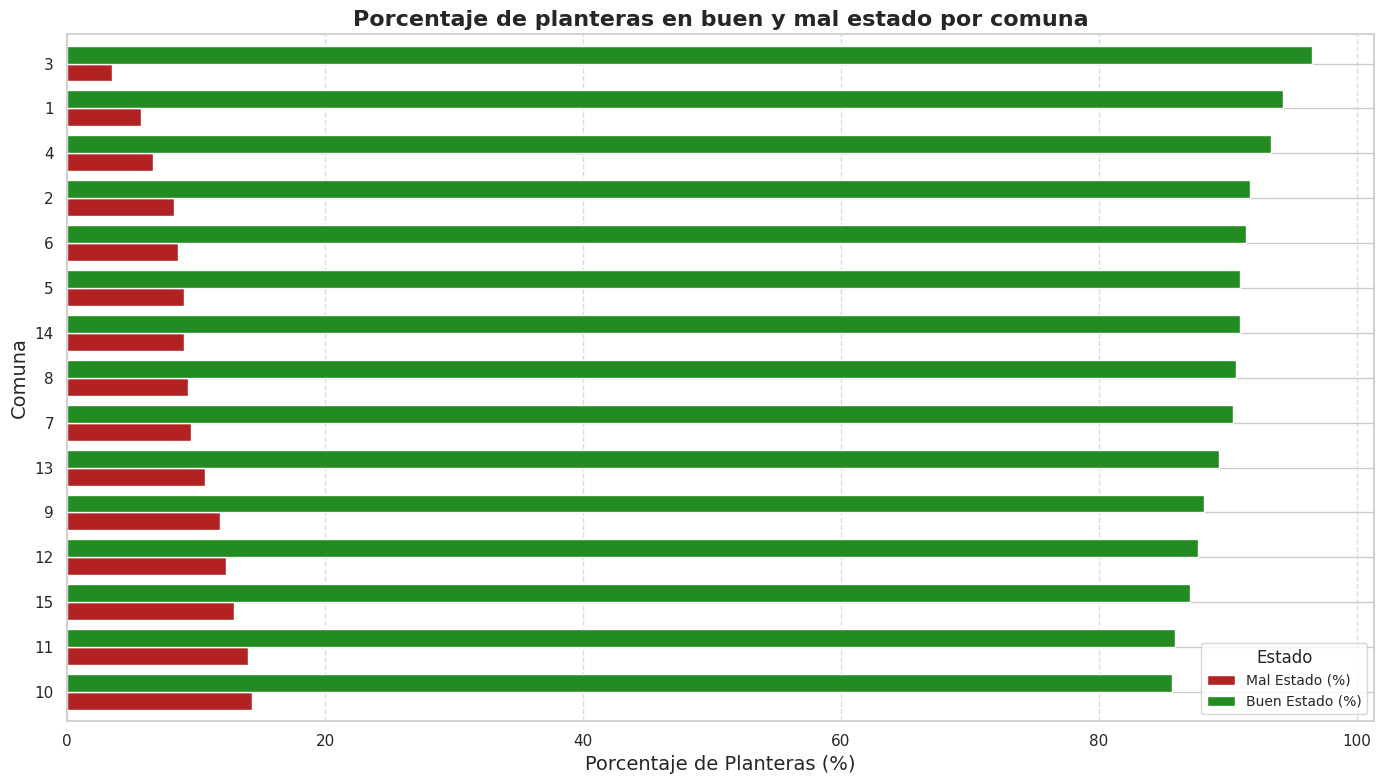

In [ ]:
datasetH4= copiaDataset[["comuna","estado_plantera"]].copy()
datasetH4["buen_estado"] = 0

m_estado = (
    (datasetH4["estado_plantera"]== "subocupada")|
    (datasetH4["estado_plantera"]=="parcialmente cerrada") |
    (datasetH4["estado_plantera"]=="sobreocupada") | 
    (datasetH4["estado_plantera"]=="vacía")
)
datasetH4.loc[m_estado, "buen_estado"] = 0

b_estado = (
    (datasetH4["estado_plantera"]=="ocupada") | 
    (datasetH4["estado_plantera"]=="cerrada")
)

datasetH4.loc[b_estado, "buen_estado"] = 1
print("Conteo usando método .loc:")
print(datasetH4["buen_estado"].value_counts())

#obtenemos los porcentajes de buen y mal estado de las planteras por comuna

conteo_por_estado = datasetH4.groupby(["comuna", "buen_estado"]).size().reset_index(name="conteo")

# Calcula el total de planteras por cada comuna para el porcentaje
total_por_comuna = datasetH4.groupby("comuna").size().reset_index(name="total_comuna")

# 2. Combinar y calcular el porcentaje
resultados = pd.merge(conteo_por_estado, total_por_comuna, on="comuna")

resultados["porcentaje"] = (resultados["conteo"] / resultados["total_comuna"]) * 100

# 3. Pivote para una mejor visualización
# Transforma la tabla para que los estados (0 y 1) sean columnas
resultados_comuna = resultados.pivot(
    index="comuna", 
    columns="buen_estado", 
    values="porcentaje"
).fillna(0).rename(columns={0: "Mal Estado (%)", 1: "Buen Estado (%)"})

# 4. (Opcional) Agregar el conteo total de planteras por comuna
resultados_comuna["Total Planteras"] = total_por_comuna.set_index("comuna")["total_comuna"]

# Mostrar el resultado final
print("--- Porcentaje de Buen y Mal Estado de Planteras por Comuna ---")
print(resultados_comuna.round(2))

df_grafico = resultados_comuna.drop(columns=["Total Planteras"])

# Reordenar las comunas por el porcentaje de Mal Estado (para ver las peores comunas primero)
df_grafico = df_grafico.sort_values(by="Mal Estado (%)", ascending=False)

# 2. Configurar el gráfico
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Usar el método plot de Pandas/Matplotlib para crear el gráfico de barras
# kind='barh' para barras horizontales, que son mejores para muchas categorías (comunas)
df_grafico.plot(
    kind="barh", 
    ax=ax, 
    color={"Buen Estado (%)": "forestgreen", "Mal Estado (%)": "firebrick"},
    width=0.8 # Ancho de las barras
)

# 3. Personalizar el gráfico
plt.title("Porcentaje de planteras en buen y mal estado por comuna", fontsize=16, fontweight="bold")
plt.xlabel("Porcentaje de Planteras (%)", fontsize=14)
plt.ylabel("Comuna", fontsize=14)
plt.legend(title="Estado", loc="lower right", fontsize=10)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout() # Asegura que las etiquetas no se corten

plt.show()


**La hipotesis **

### Hipotesis 5
- "Existen regiones con mayor proporcion de Platanus x acerifolia, especie que produce alergias"


    comuna    region  prop_platanus
0        1   noreste       0.119311
1        2   noreste       0.098384
2        3   sudeste       0.049550
3        4   sudeste       0.070834
4        5   sudeste       0.115738
5        6   sudeste       0.066577
6        7   sudeste       0.070993
7        8  sudoeste       0.043563
8        9  sudoeste       0.072105
9       10  sudoeste       0.076359
10      11  noroeste       0.109588
11      12  noroeste       0.069658
12      13   noreste       0.081062
13      14   noreste       0.153232
14      15  noroeste       0.135262

--- PRUEBA DE LEVENE (Homocedasticidad) ---
Estadístico de Levene: 0.3865
p-value: 0.7650
NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES

--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---
Estadístico de Shapiro-Wilk: 0.9498
p-value: 0.5210
NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL


/tmp/ipykernel_4827/1014772100.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0, 0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)


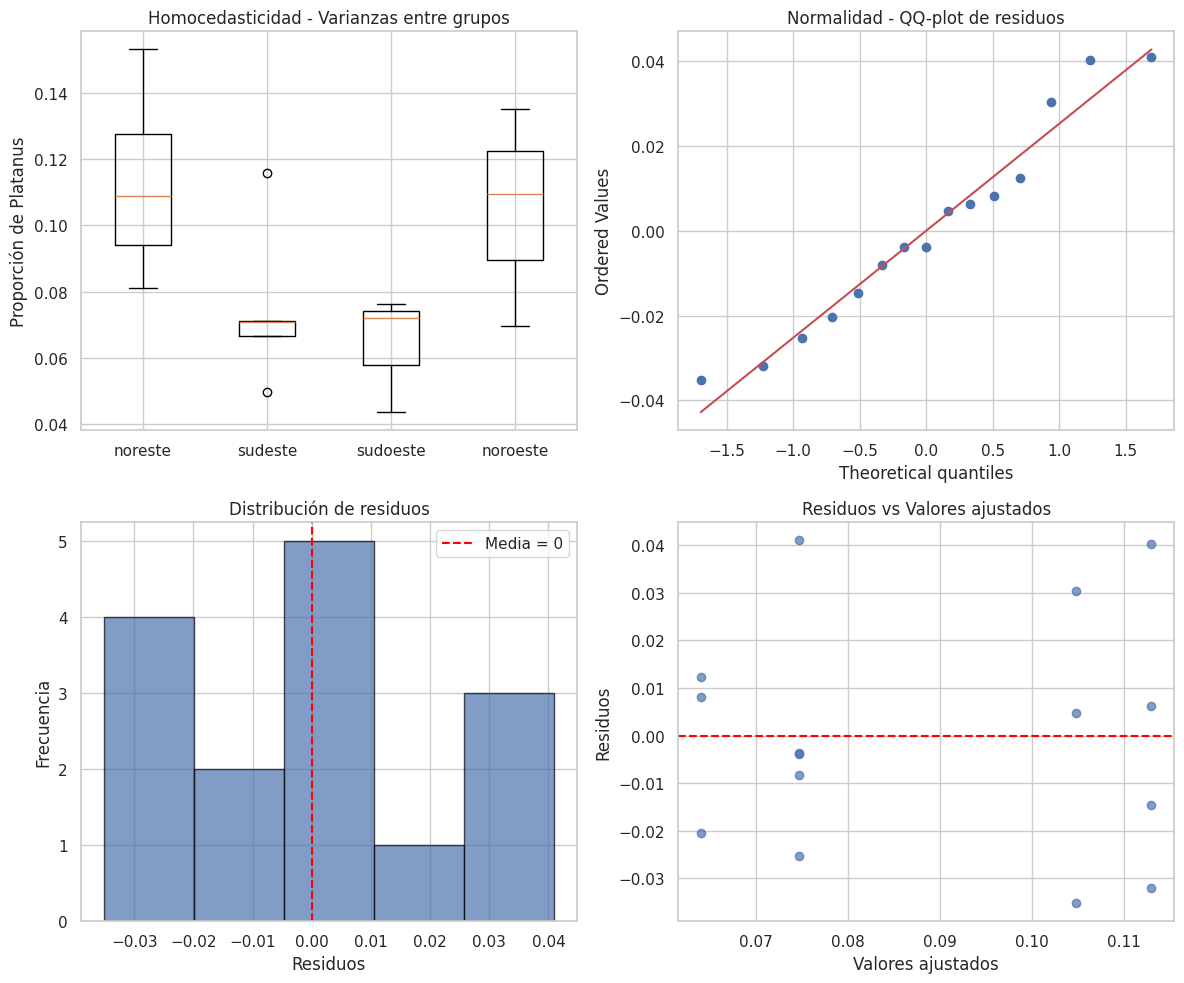

Estadístico F: 2.6831
p-value: 0.0982
0.09820539886557537
Resultado NO significativo: No hay diferencias entre regiones


In [ ]:
#H0:las proporciones de Platanus x acerifolia son iguales en todas las regiones
#H1: existen diferencias en la proporción de Platanus x acerifolia entre las regiones.

datasetH5 = copiaDataset[["comuna","nombre_cientifico"]].copy()

#planteamos cuatro grupos: noreste,sureste,noroeste,sudoeste
mapeo_regiones={
    1 : "noreste",
    2 : "noreste",
    3 : "sudeste",
    4 : "sudeste",
    5 : "sudeste",
    6 : "sudeste",
    7 : "sudeste",
    8 : "sudoeste",
    9 : "sudoeste",
    10 : "sudoeste",
    11 : "noroeste",
    12 : "noroeste",
    13 : "noreste",
    14 : "noreste",
    15 : "noroeste",
}
datasetH5["region"]=datasetH5["comuna"].map(mapeo_regiones)
datasetH5["es_platanus"] = datasetH5["nombre_cientifico"].str.contains("platanus", case =False,na=False)


proporcion = datasetH5.groupby(["comuna", "region"]).agg(
    prop_platanus=("es_platanus", "mean")  # "mean" de booleanos es la proporción
).reset_index()

print(proporcion)

regiones = proporcion['region'].unique()
datos_por_region = {}

for region in regiones:
    datos_por_region[region] = proporcion[proporcion['region'] == region]['prop_platanus'].values

# 2. Verificar HOMOCEDASTICIDAD (igualdad de varianzas) - Test de Levene
print("\n--- PRUEBA DE LEVENE (Homocedasticidad) ---")
levene_stat, levene_p = levene(*datos_por_region.values())
print(f"Estadístico de Levene: {levene_stat:.4f}")
print(f"p-value: {levene_p:.4f}")

if levene_p > 0.05:
    print("NO se rechaza la hipótesis nula: LAS VARIANZAS SON IGUALES")
    homocedasticidad = True
else:
    print("SE RECHAZA la hipótesis nula: LAS VARIANZAS NO SON IGUALES")
    homocedasticidad = False

# 3. Verificar NORMALIDAD - Test de Shapiro-Wilk en los residuos
print("\n--- PRUEBA DE NORMALIDAD (Shapiro-Wilk en residuos) ---")

# Calcular residuos (diferencia entre cada valor y la media de su grupo)
residuos = []
for idx, row in proporcion.iterrows():
    region = row['region']
    media_region = np.mean(datos_por_region[region])
    residuo = row['prop_platanus'] - media_region
    residuos.append(residuo)

residuos = np.array(residuos)

# Test de Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuos)
print(f"Estadístico de Shapiro-Wilk: {shapiro_stat:.4f}")
print(f"p-value: {shapiro_p:.4f}")

if shapiro_p > 0.05:
    print("NO se rechaza la hipótesis nula: LOS RESIDUOS SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = True
else:
    print("SE RECHAZA la hipótesis nula: LOS RESIDUOS NO SIGUEN DISTRIBUCIÓN NORMAL")
    normalidad = False

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Gráfico 1: Boxplot por región (homocedasticidad)
axes[0, 0].boxplot([datos_por_region[region] for region in regiones], labels=regiones)
axes[0, 0].set_title('Homocedasticidad - Varianzas entre grupos')
axes[0, 0].set_ylabel('Proporción de Platanus')

# Gráfico 2: QQ-plot de residuos (normalidad)
stats.probplot(residuos, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Normalidad - QQ-plot de residuos')

# Gráfico 3: Histograma de residuos
axes[1, 0].hist(residuos, bins=5, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=0, color='red', linestyle='--', label='Media = 0')
axes[1, 0].set_title('Distribución de residuos')
axes[1, 0].set_xlabel('Residuos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()

# Gráfico 4: Residuos vs Valores ajustados
valores_ajustados = [np.mean(datos_por_region[row['region']]) for idx, row in proporcion.iterrows()]
axes[1, 1].scatter(valores_ajustados, residuos, alpha=0.7)
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_title('Residuos vs Valores ajustados')
axes[1, 1].set_xlabel('Valores ajustados')
axes[1, 1].set_ylabel('Residuos')

plt.tight_layout()
plt.show()

#tanto el p valor del test de levene como de shapiro nos dio >0,05, 
# por lo tanto se cumplen los supuestos de ANOVA y podemos hacer el test parametrico

# ANOVA paramétrico
anova_result = stats.f_oneway(*[datos_por_region[region] for region in regiones])
print(f"Estadístico F: {anova_result.statistic:.4f}")
print(f"p-value: {anova_result.pvalue:.4f}")

print(anova_result.pvalue)
print("Resultado NO significativo: No hay diferencias entre regiones")




### MULTIVARIADA

### Hipotesis 6
- El indice de daño a la infraestructura (rotura de veredas) no se distribuye aleatoriamente, sino que es significativamente mayor en aquellas comunas que presentan una alta densidad de especies de arbolado específicas en aceras angostas.

/tmp/ipykernel_4827/1319892203.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datasetH6["especies"]= datasetH6["nombre_cientifico"].where(datasetH6["nombre_cientifico"].isin(conteoEspecie),other="otras")
/tmp/ipykernel_4827/1319892203.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datasetH6["ancho_necesario"] = datasetH6["especies"].map(map_ancho_necesario).fillna(promMinimo)
/tmp/ipykernel_4827/1319892203.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

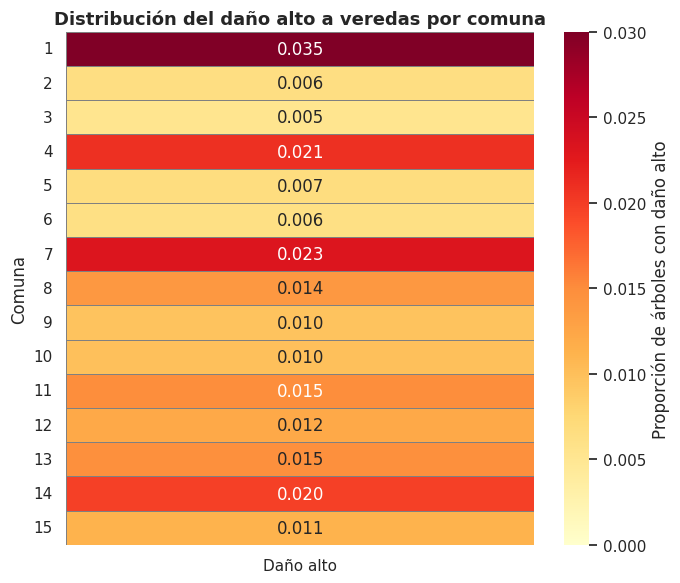

In [ ]:
copiaDataset["nombre_cientifico"].value_counts()

datasetH6=copiaDataset[["nombre_cientifico","comuna","ancho_acera"]]

conteoEspecie= datasetH6["nombre_cientifico"].value_counts().head(5).index

datasetH6["especies"]= datasetH6["nombre_cientifico"].where(datasetH6["nombre_cientifico"].isin(conteoEspecie),other="otras")

# calculamos para las especies en "otras", el promedio entre los min de ancho de acera necesarios 
promMinimo=2.96

map_ancho_necesario= {
    "fraxinus pennsylvanica": 2.4,
    "platanus x acerifolia": 4,
    "ficus benjamina": 4,
    "tilia x moltkei": 3.8,
    "melia azedarach": 2.5
}

# asignamos el valor
datasetH6["ancho_necesario"] = datasetH6["especies"].map(map_ancho_necesario).fillna(promMinimo)
#calcula qué proporción del ancho ideal tiene realmente la vereda y lo transforma a una medida de deficit
datasetH6["indice_de_danio"] = 1 - (datasetH6["ancho_acera"] / datasetH6["ancho_necesario"]) #si ancho_acera es nulo, el indice queda nulo
#asegura que si la vereda es más ancha que la necesaria (cociente > 1) no te de un valor negativo
datasetH6.loc[datasetH6["indice_de_danio"] < 0, "indice_de_danio"] = 0

def clasificar_danio(x):
    if x <= 0.20:
        return "bajo"
    elif x <= 0.50:
        return "medio"
    else:
        return "alto"

datasetH6["nivel_danio"] = datasetH6["indice_de_danio"].apply(clasificar_danio)

#porcentaje de danio en cada comuna por nivel
danio_por_comuna = (
    datasetH6.groupby("comuna")["nivel_danio"]
    .value_counts(normalize=True) # normalza para que se expresen como proporciones
    .unstack(fill_value=0)
)

# saca el nombre del eje x
danio_por_comuna.columns.name = None

#mapa de calor
plt.figure(figsize=(7,6))
sns.heatmap(
    danio_por_comuna[["alto"]].rename(columns={"alto": "Daño alto"}),
    cmap="YlOrRd",
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="gray",
    vmin=0, vmax=0.03,
    cbar_kws={"label": "Proporción de árboles con daño alto"}
)
plt.title("Distribución del daño alto a veredas por comuna", fontsize=13, weight="bold")
plt.ylabel("Comuna")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



